In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Train.csv')

### Missing Values

In [3]:
df.isnull().sum()[df.isnull().sum()!=0]

ecec20         5
hp20           5
xhp20          5
BulkDensity    4
dtype: int64

In [4]:
for column in df.columns:
  if df[column].isnull().any():
    df[column].fillna(df[column].mean(), inplace=True)
    

### EDA

In [5]:
df.columns

Index(['site', 'PID', 'lon', 'lat', 'pH', 'alb', 'bio1', 'bio12', 'bio15',
       'bio7', 'bp', 'cec20', 'dows', 'ecec20', 'hp20', 'ls', 'lstd', 'lstn',
       'mb1', 'mb2', 'mb3', 'mb7', 'mdem', 'para', 'parv', 'ph20', 'slope',
       'snd20', 'soc20', 'tim', 'wp', 'xhp20', 'BulkDensity', 'N', 'P', 'K',
       'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B'],
      dtype='object')

In [6]:
df.drop(columns=['site','lon','lat'],inplace=True)

In [7]:
df.columns

Index(['PID', 'pH', 'alb', 'bio1', 'bio12', 'bio15', 'bio7', 'bp', 'cec20',
       'dows', 'ecec20', 'hp20', 'ls', 'lstd', 'lstn', 'mb1', 'mb2', 'mb3',
       'mb7', 'mdem', 'para', 'parv', 'ph20', 'slope', 'snd20', 'soc20', 'tim',
       'wp', 'xhp20', 'BulkDensity', 'N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe',
       'Mn', 'Zn', 'Cu', 'B'],
      dtype='object')

In [13]:
target_columns = ['N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

per_target_importances = {}

for nutrient in target_columns:
    X = df.drop(columns=target_columns + ['PID'])
    y = df[nutrient]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    importances = model.feature_importances_
    feature_names = X.columns
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # Convert to percentage of total importance
    importance_df['Importance (%)'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
    
    per_target_importances[nutrient] = importance_df

    # Print the percentage importances for this nutrient
    print(f"Feature importances for {nutrient}:")
    print(importance_df[['Feature', 'Importance (%)']])
    
    print("\n" + "="*40 + "\n")
    
    # ---- New: Create list 'selected_features_{nutrient}' keeping 80% of total importance ----
    importance_df['Cumulative (%)'] = importance_df['Importance (%)'].cumsum()
    selected = importance_df[importance_df['Cumulative (%)'] <= 80]['Feature'].tolist()

    # Add one more feature if 80% was not reached exactly
    if len(selected) < len(importance_df) and importance_df['Cumulative (%)'].iloc[len(selected)] < 80:
        selected.append(importance_df['Feature'].iloc[len(selected)])

    # Create a variable dynamically named 'selected_features_{nutrient}'
    globals()[f'selected_features_{nutrient}'] = selected


Feature importances for N:
        Feature  Importance (%)
0            pH       22.610386
12         lstd        9.545344
21         ph20        8.244521
24        soc20        6.348211
15          mb2        4.244223
8          dows        3.368163
3         bio12        3.335776
13         lstn        2.711888
4         bio15        2.564808
18         mdem        2.525634
5          bio7        2.401593
9        ecec20        2.294228
6            bp        2.239915
19         para        2.129034
22        slope        2.052380
17          mb7        2.032248
25          tim        1.951394
20         parv        1.918474
26           wp        1.819810
1           alb        1.767681
14          mb1        1.749021
27        xhp20        1.709013
23        snd20        1.707449
2          bio1        1.664475
28  BulkDensity        1.660564
7         cec20        1.620211
16          mb3        1.502783
10         hp20        1.483177
11           ls        0.797597


Feature imp

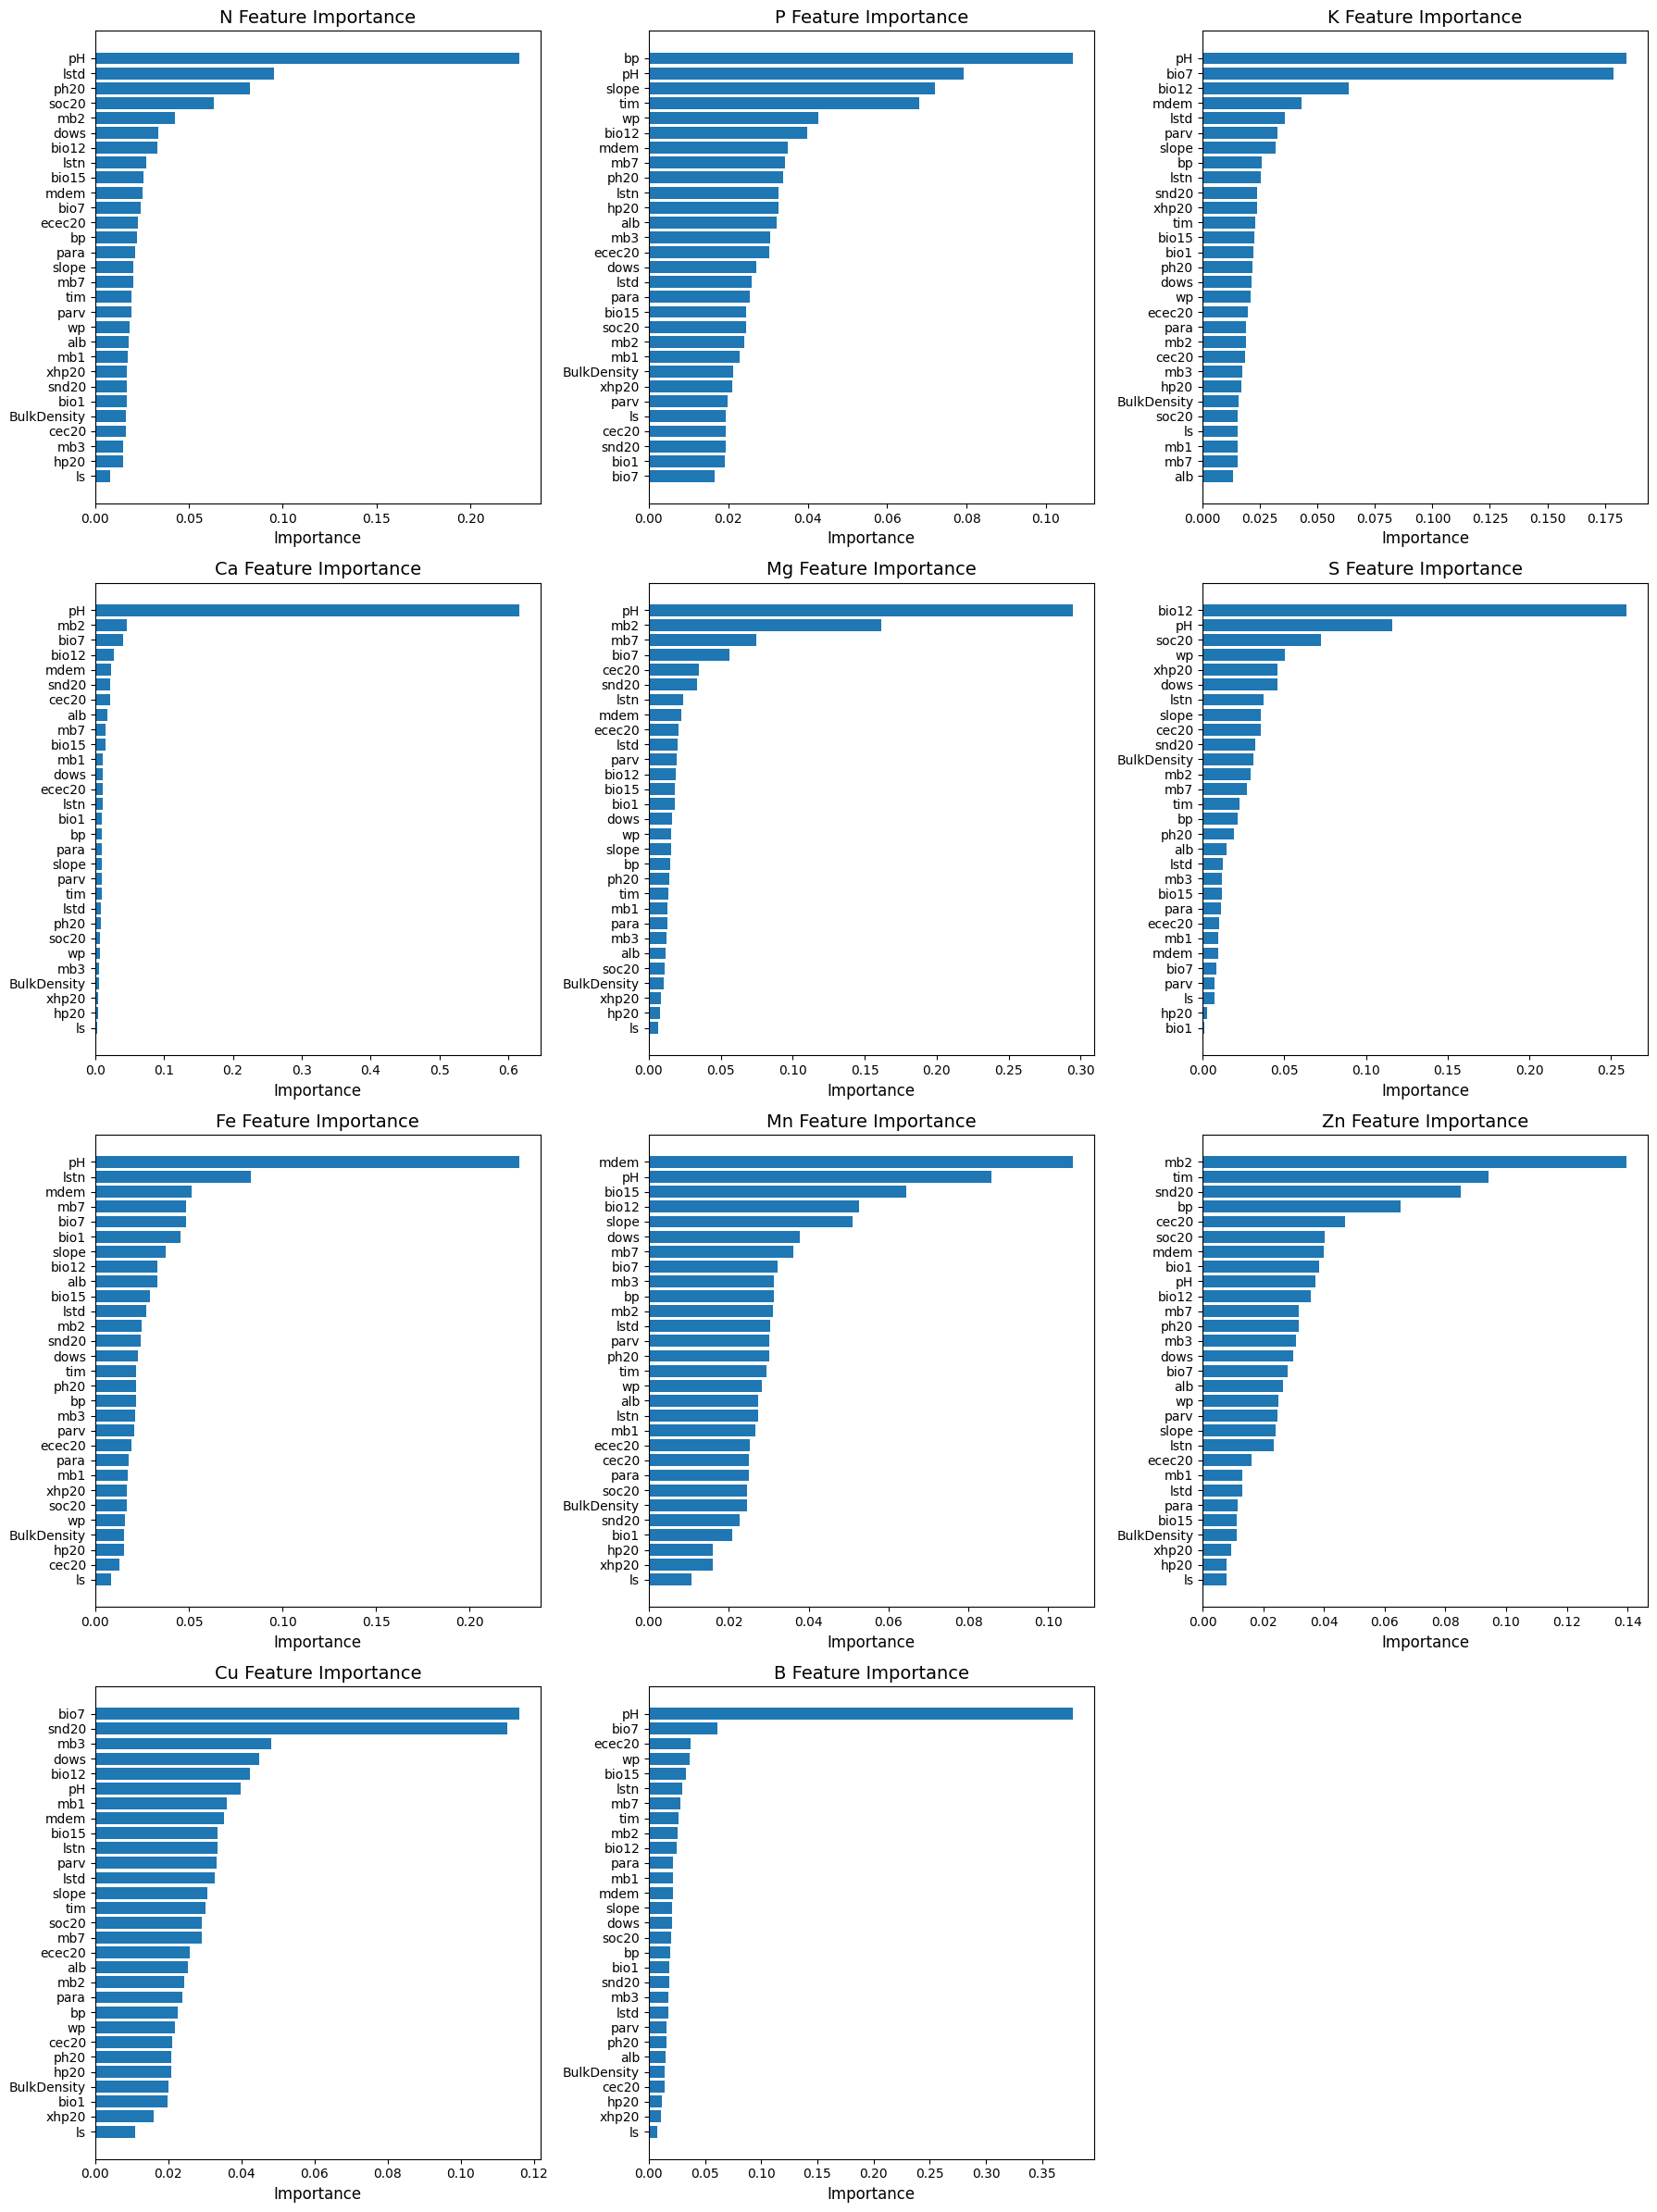

In [66]:
import matplotlib.pyplot as plt
n_targets = len(per_target_importances)
ncols = 3
nrows = (n_targets + ncols - 1) // ncols  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 6 * nrows))
axes = axes.flatten()
for idx, (nutrient, imp_df) in enumerate(per_target_importances.items()):
    ax = axes[idx]
    ax.barh(imp_df['Feature'], imp_df['Importance'])
    ax.set_title(f'{nutrient} Feature Importance', fontsize=14)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.savefig("feature_importance_all_nutrients.png", dpi=300) 
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
def predire(Nutrient,Nutrient_df) :
    X = Nutrient_df.drop(columns=Nutrient)
    y = df[Nutrient]
    X_test = df.drop(columns=['PID',"site"])
    

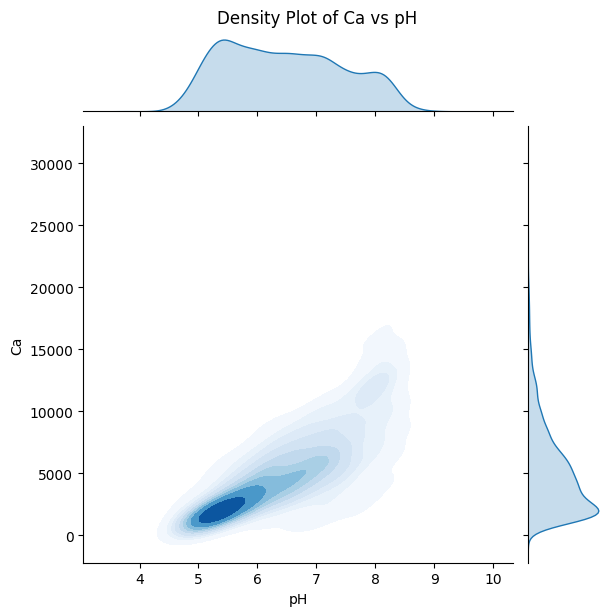

In [61]:
sns.jointplot(data=df, x='pH', y='Ca', kind='kde', fill=True, cmap='Blues', height=6)
plt.suptitle("Density Plot of Ca vs pH", y=1.02)
plt.show()


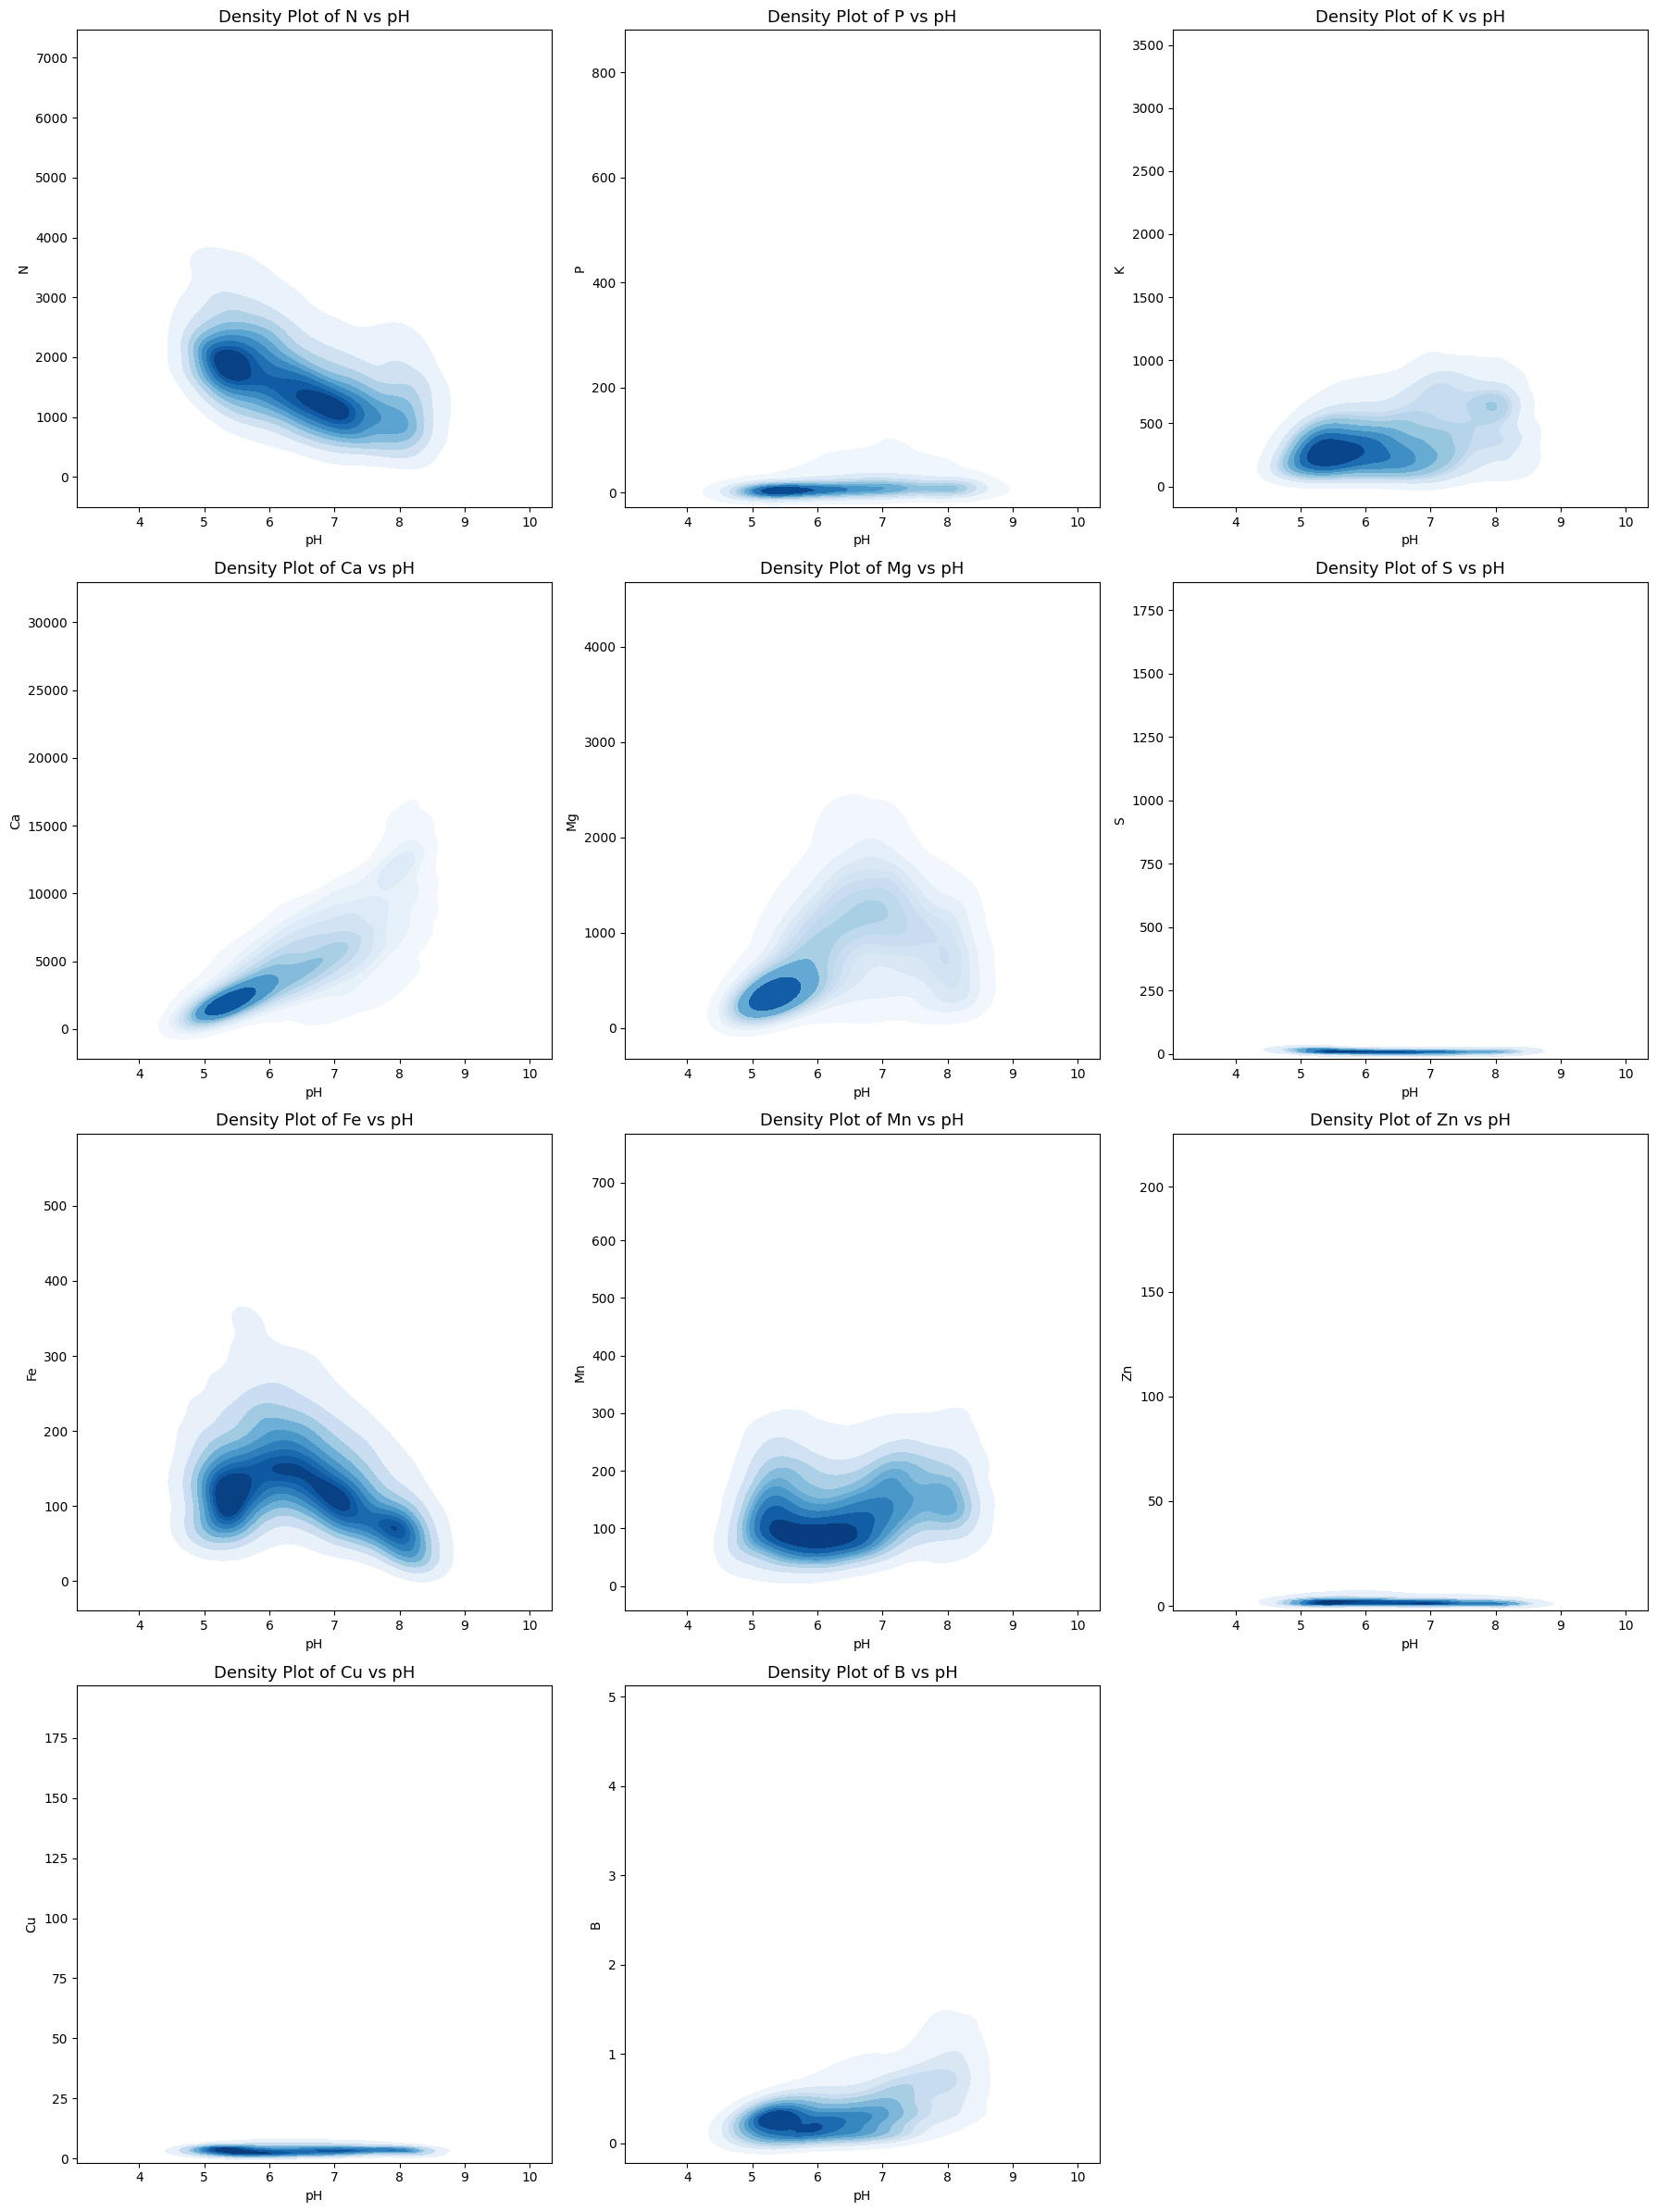

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of nutrients
nutrients = ['N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

# Grid configuration
ncols = 3
nrows = (len(nutrients) + ncols - 1) // ncols

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 6 * nrows))
axes = axes.flatten()

# Plot each nutrient's KDE vs pH
for idx, nutrient in enumerate(nutrients):
    ax = axes[idx]
    sns.kdeplot(
        data=df,
        x='pH',
        y=nutrient,
        fill=True,
        cmap='Blues',
        thresh=0.05,
        ax=ax
    )
    ax.set_title(f'Density Plot of {nutrient} vs pH', fontsize=13)
    ax.set_xlabel("pH")
    ax.set_ylabel(nutrient)

# Hide any extra unused subplots
for i in range(len(nutrients), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout and save
plt.tight_layout()
plt.savefig("all_nutrients_vs_pH_density.png", dpi=300)
plt.show()


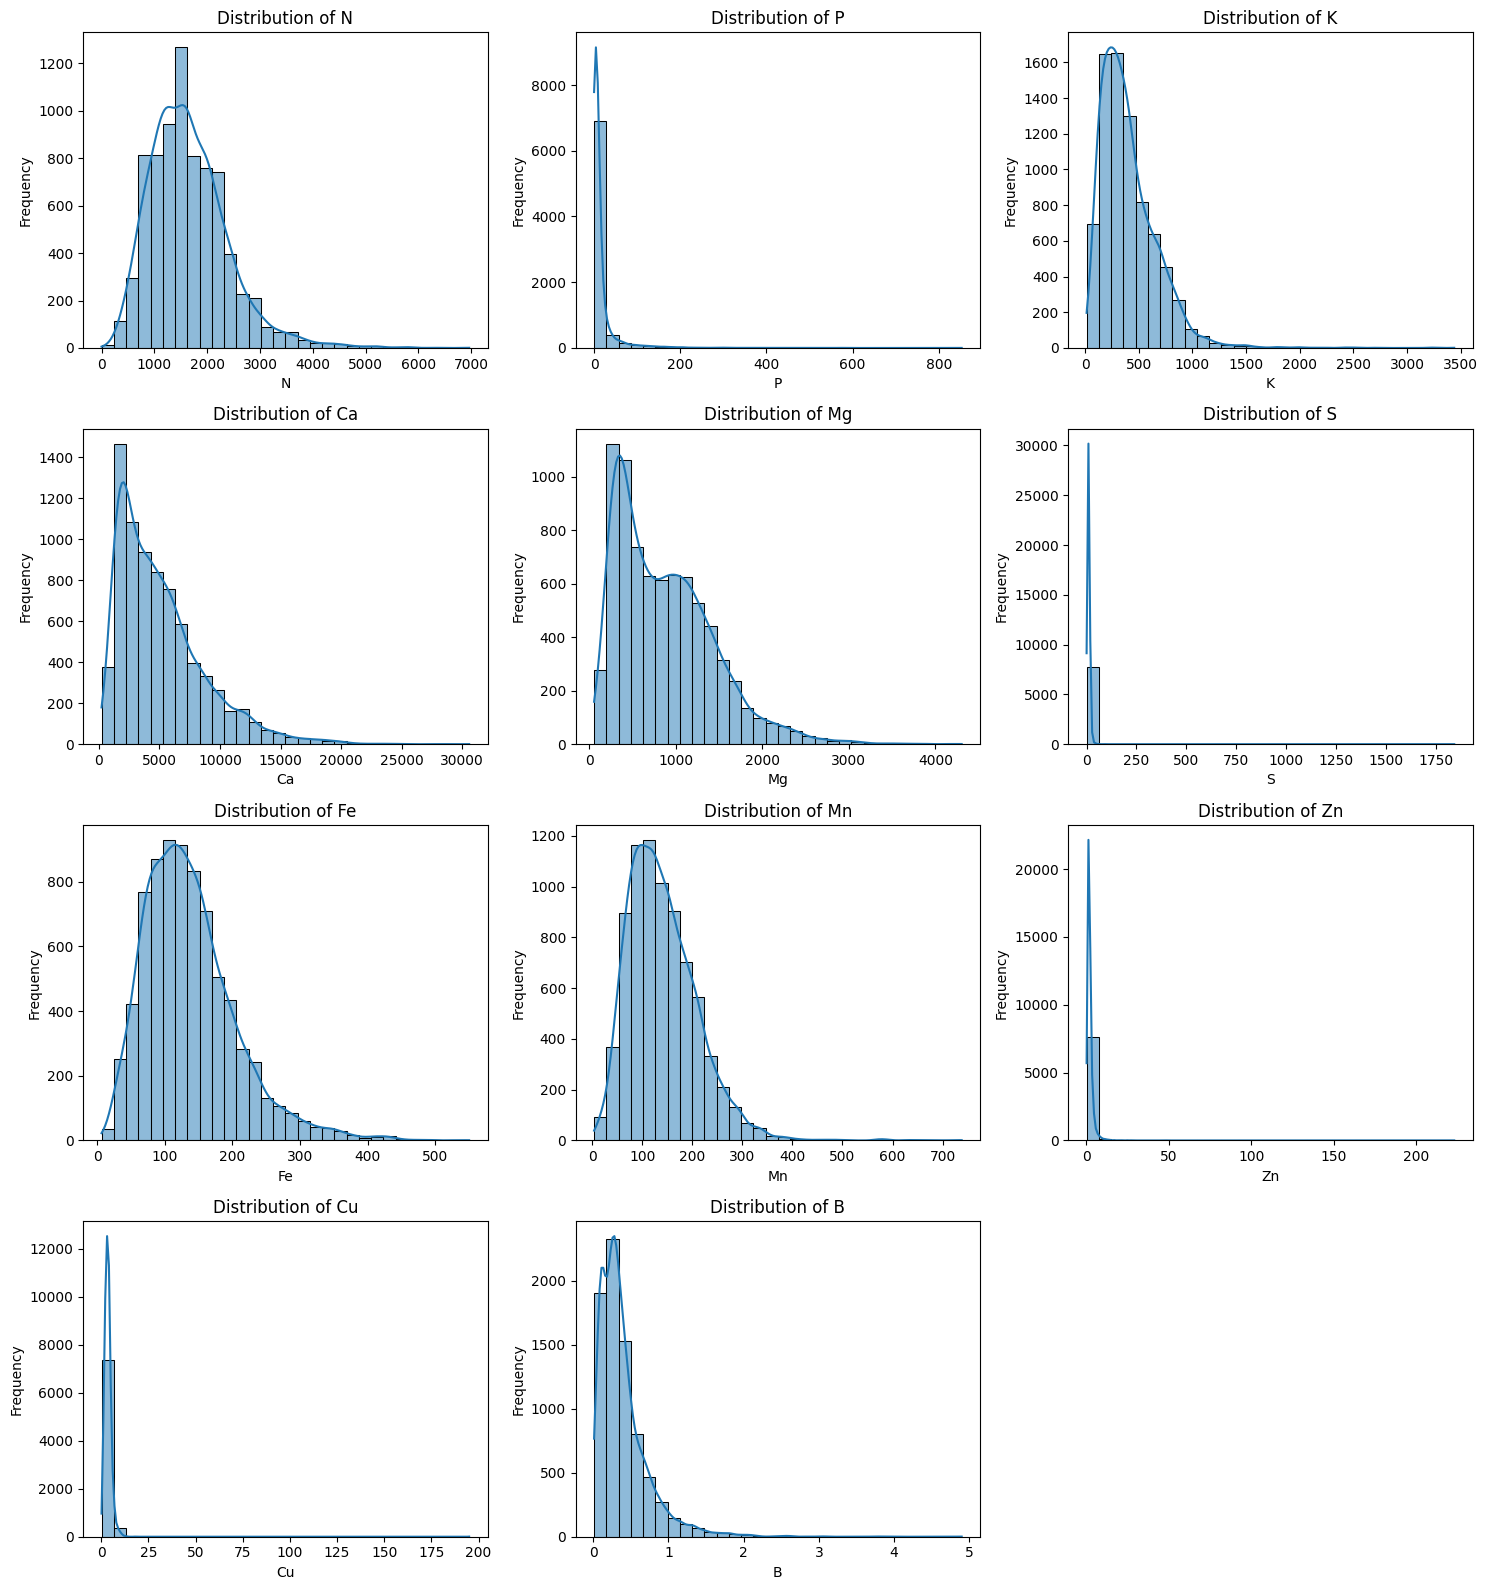

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define number of rows and columns for subplots
n = len(target_columns)
cols = 3  # Adjust columns to your preference
rows = (n + cols - 1) // cols

# Set figure size
plt.figure(figsize=(5 * cols, 4 * rows))

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[nutrient], bins=30, kde=True)
    plt.title(f'Distribution of {nutrient}')
    plt.xlabel(nutrient)
    plt.ylabel('Frequency')

plt.tight_layout()

# Save the figure
plt.savefig('nutrient_distributions.png', dpi=300)  # You can change filename and dpi

plt.show()


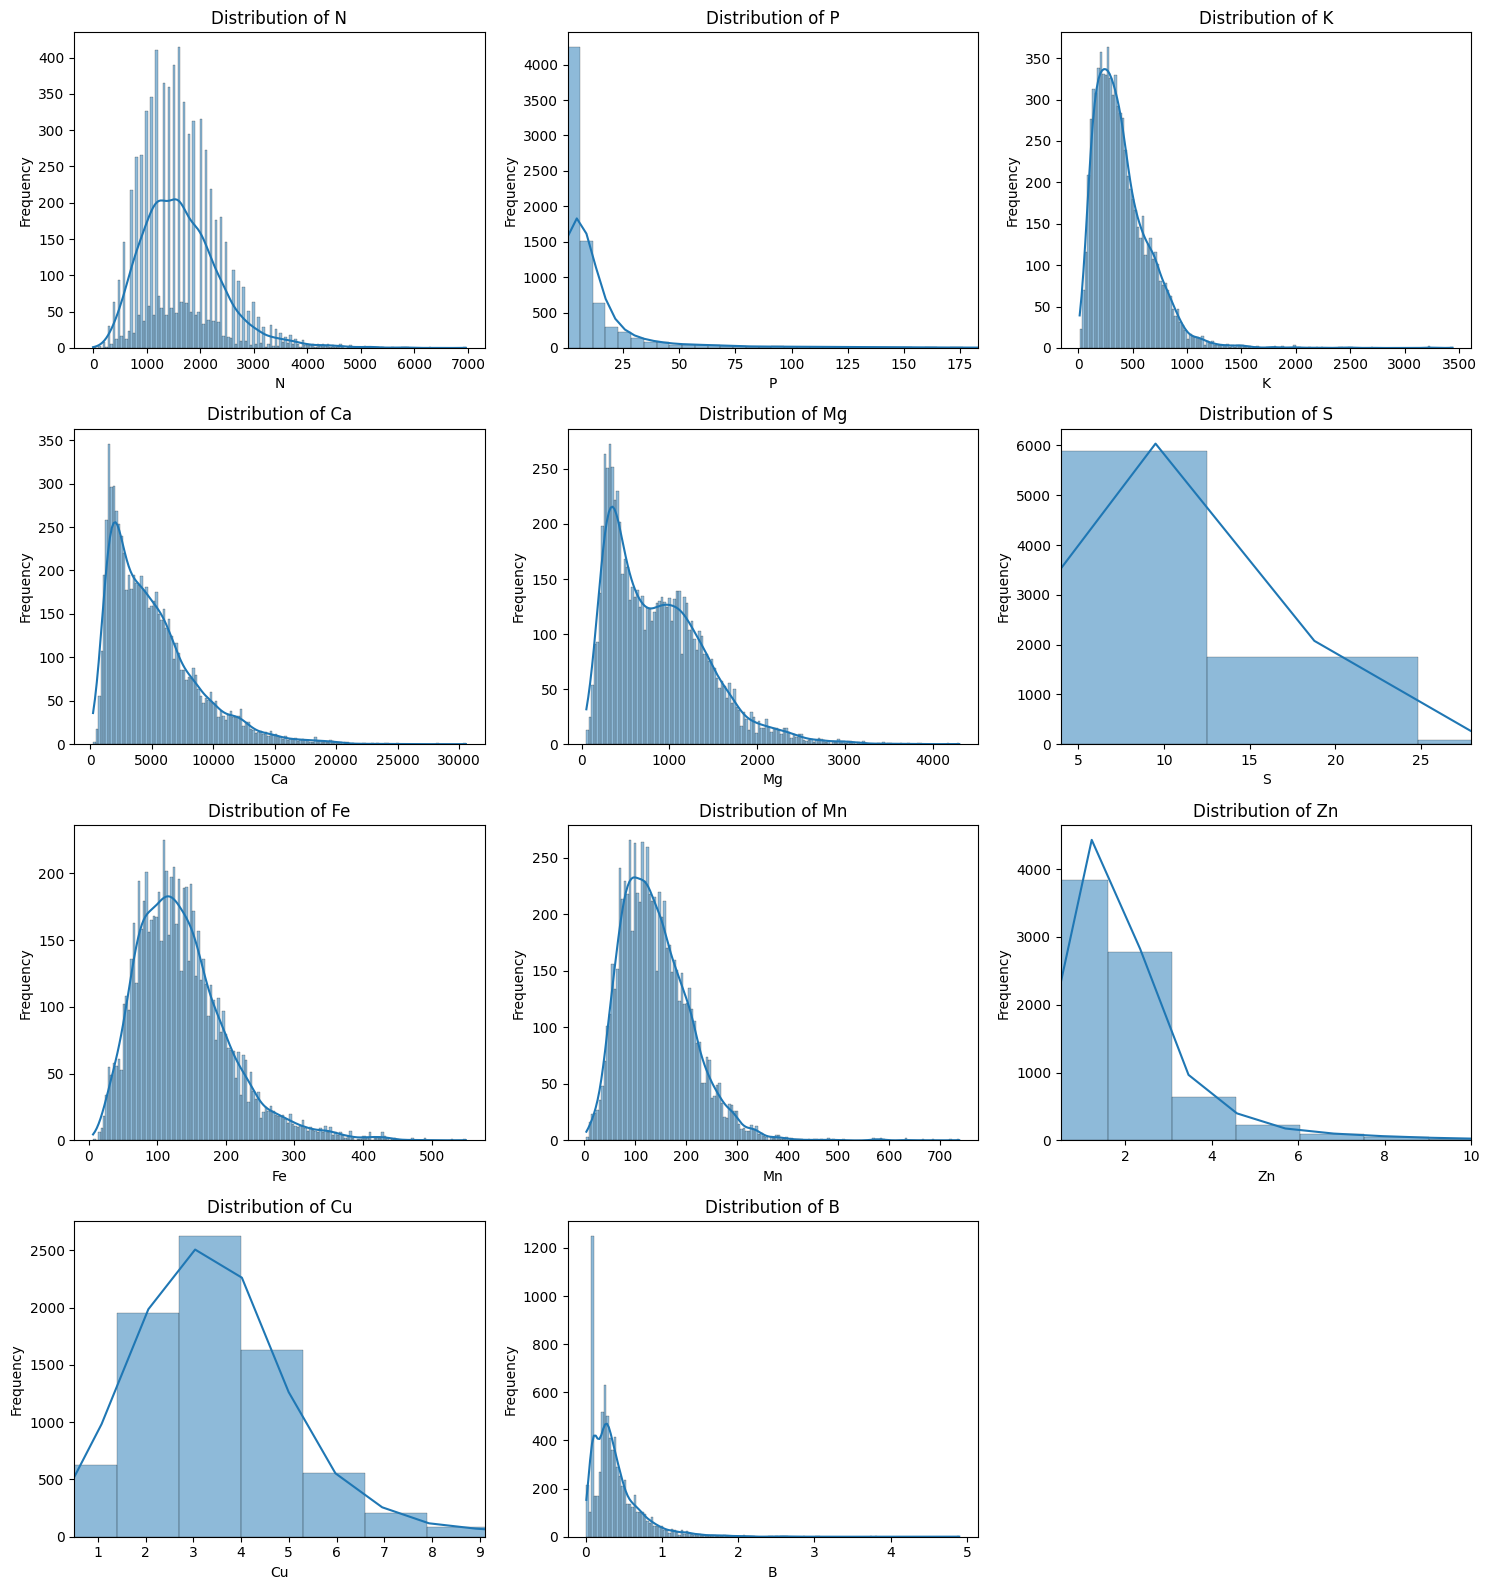

In [91]:
n = len(target_columns)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(5 * cols, 4 * rows))

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[nutrient], bins=150, kde=True)
    plt.title(f'Distribution of {nutrient}')
    plt.xlabel(nutrient)
    plt.ylabel('Frequency')
    
    # Zoom x-axis for specific nutrients with low variance
    if nutrient in ['P', 'S', 'Cu', 'Zn']:
        # Get data min/max with a small margin around the main bulk
        low, high = df[nutrient].quantile([0.01, 0.99])
        plt.xlim(low, high)

plt.tight_layout()
plt.savefig('nutrient_distributions_zoomed.png', dpi=300)
plt.show()


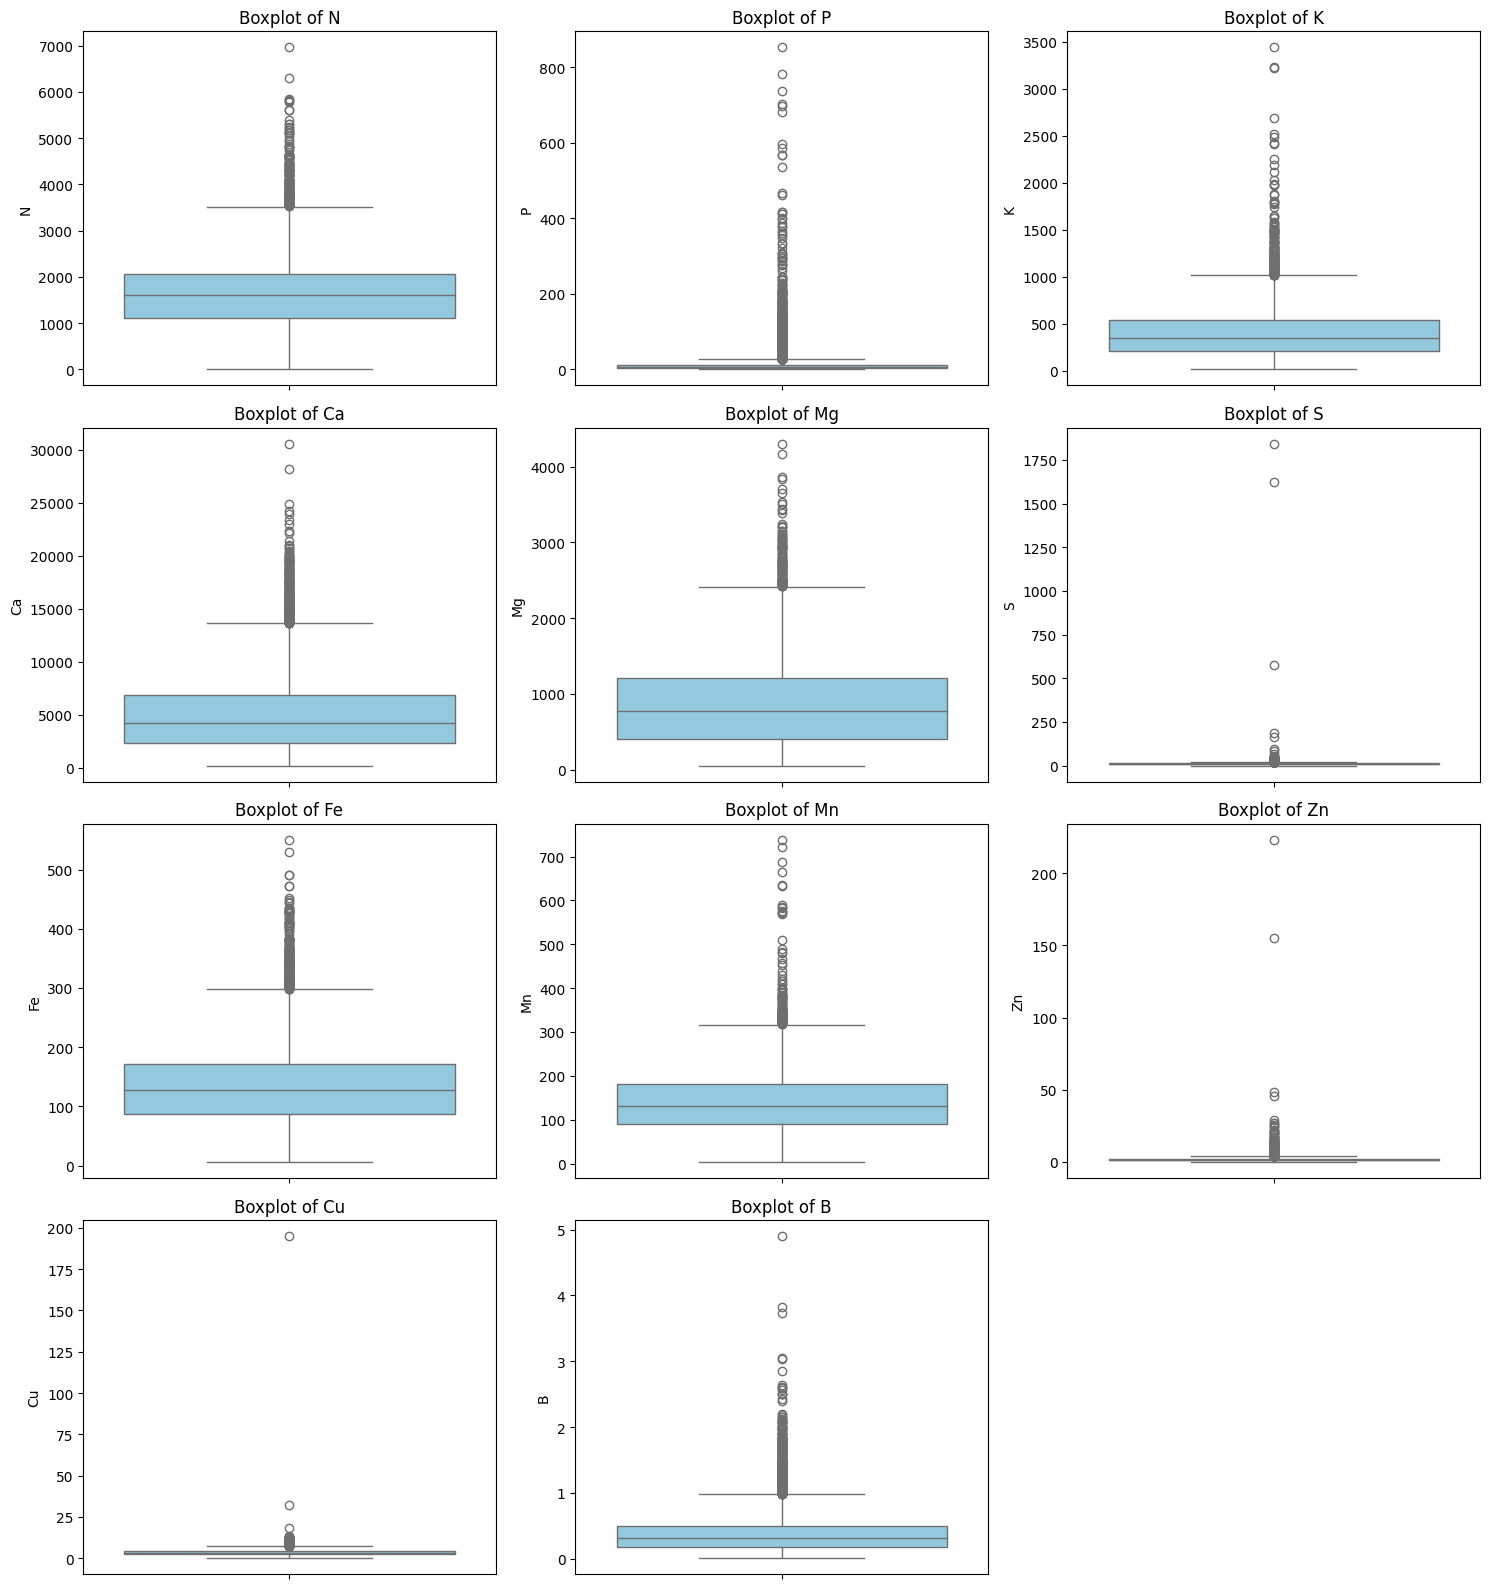

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define number of plots
n = len(target_columns)
cols = 3  # Adjust as needed
rows = (n + cols - 1) // cols

# Set figure size
plt.figure(figsize=(5 * cols, 4 * rows))

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[nutrient], color='skyblue')
    plt.title(f'Boxplot of {nutrient}')
    plt.xlabel('')
    plt.ylabel(nutrient)

plt.tight_layout()

# Save the figure
plt.savefig("nutrient_boxplots.png", dpi=300)

# Show the plots
plt.show()


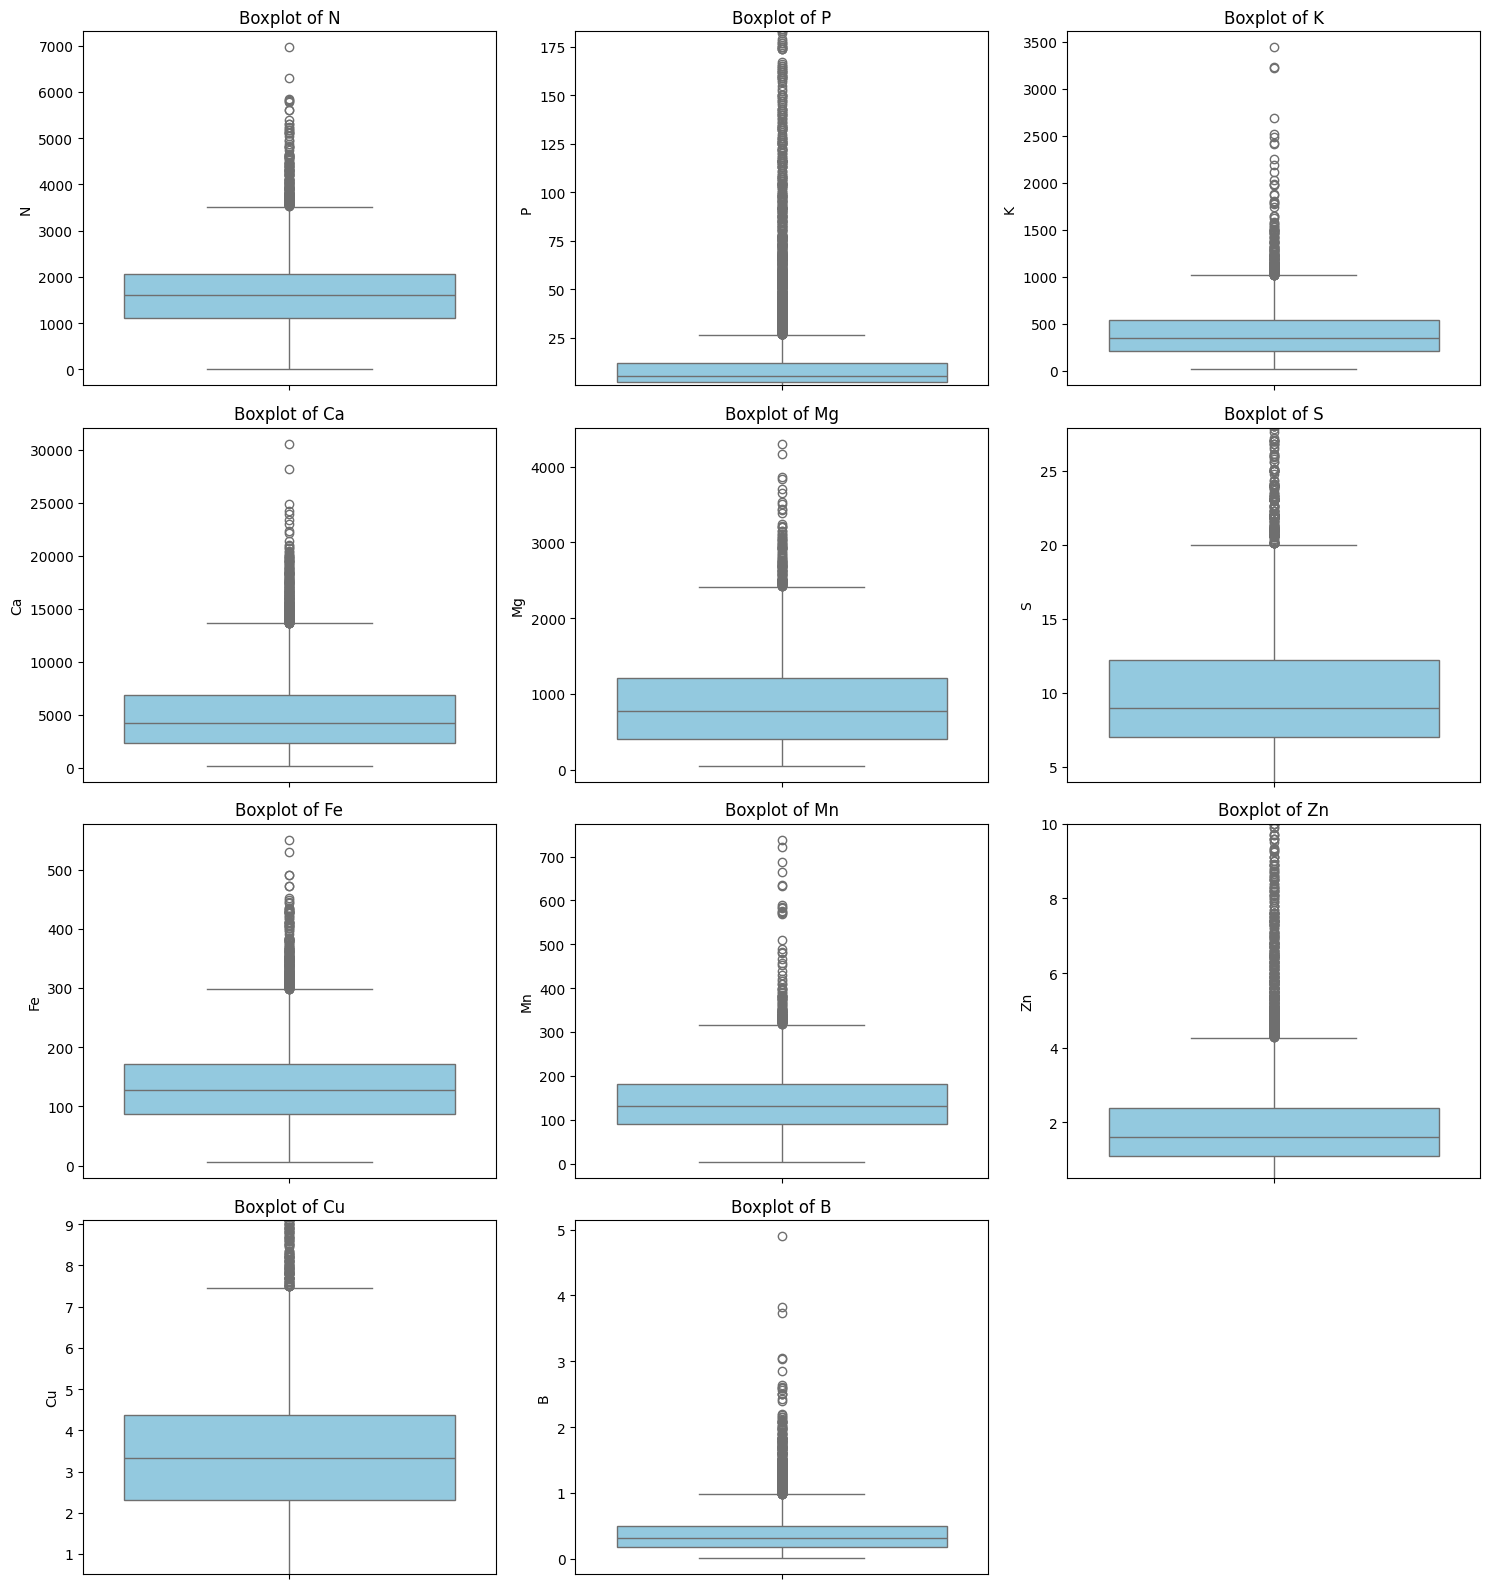

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define number of plots
n = len(target_columns)
cols = 3  # Adjust as needed
rows = (n + cols - 1) // cols

# Set figure size
plt.figure(figsize=(5 * cols, 4 * rows))

zoom_targets = ['P', 'S', 'Cu', 'Zn']

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[nutrient], color='skyblue')
    plt.title(f'Boxplot of {nutrient}')
    plt.xlabel('')
    plt.ylabel(nutrient)
    
    # Zoom y-axis for specific nutrients
    if nutrient in zoom_targets:
        low, high = df[nutrient].quantile([0.01, 0.99])
        plt.ylim(low, high)

plt.tight_layout()

# Save the figure
plt.savefig("nutrient_boxplots_zoomed.png", dpi=300)

# Show the plots
plt.show()


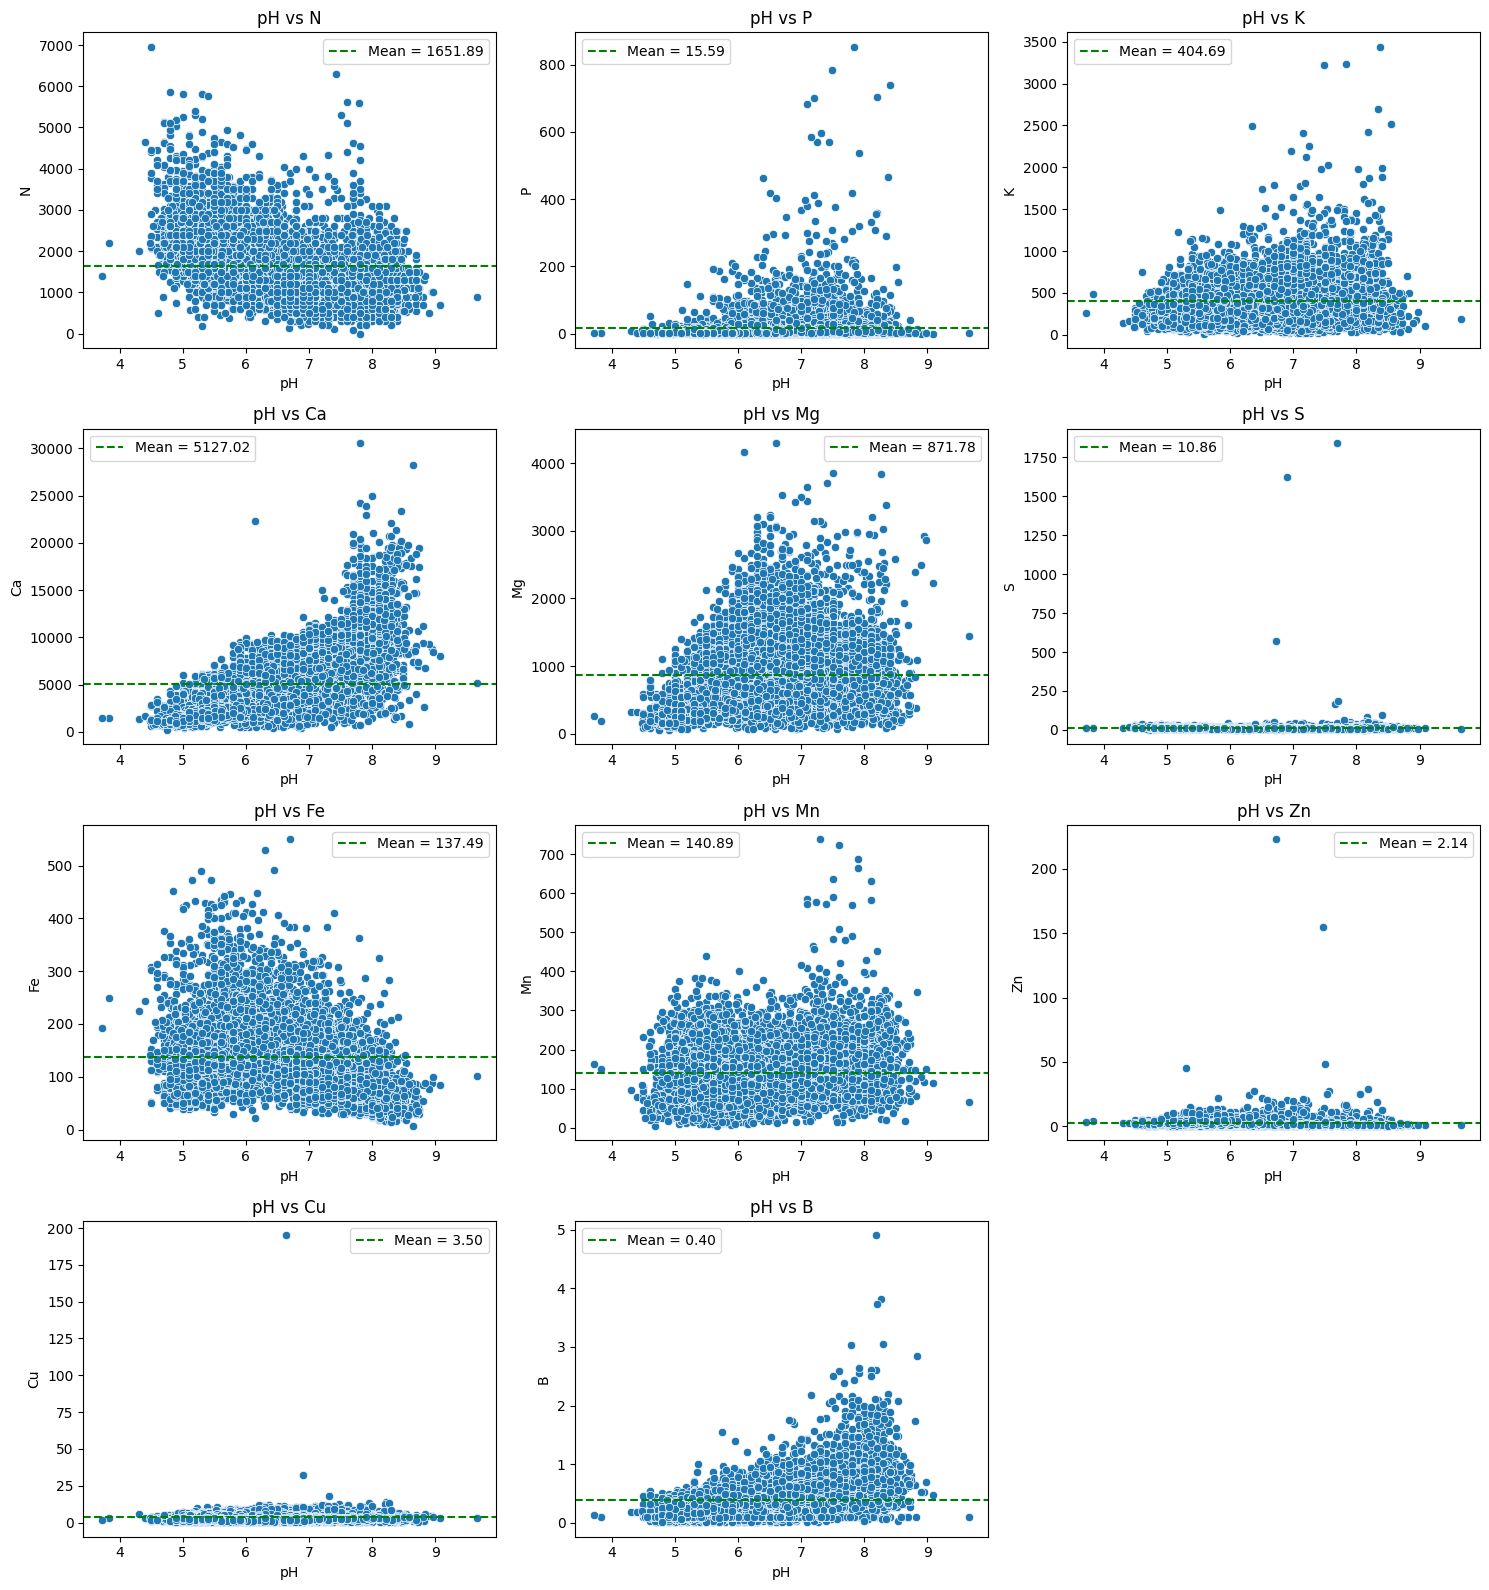

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

feature = 'pH'  # Feature for x-axis
n = len(target_columns)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.scatterplot(x=df[feature], y=df[nutrient])
    
    mean_val = df[nutrient].mean()
    plt.axhline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    
    plt.title(f'{feature} vs {nutrient}')
    plt.xlabel(feature)
    plt.ylabel(nutrient)
    plt.legend()

plt.tight_layout()
plt.show()


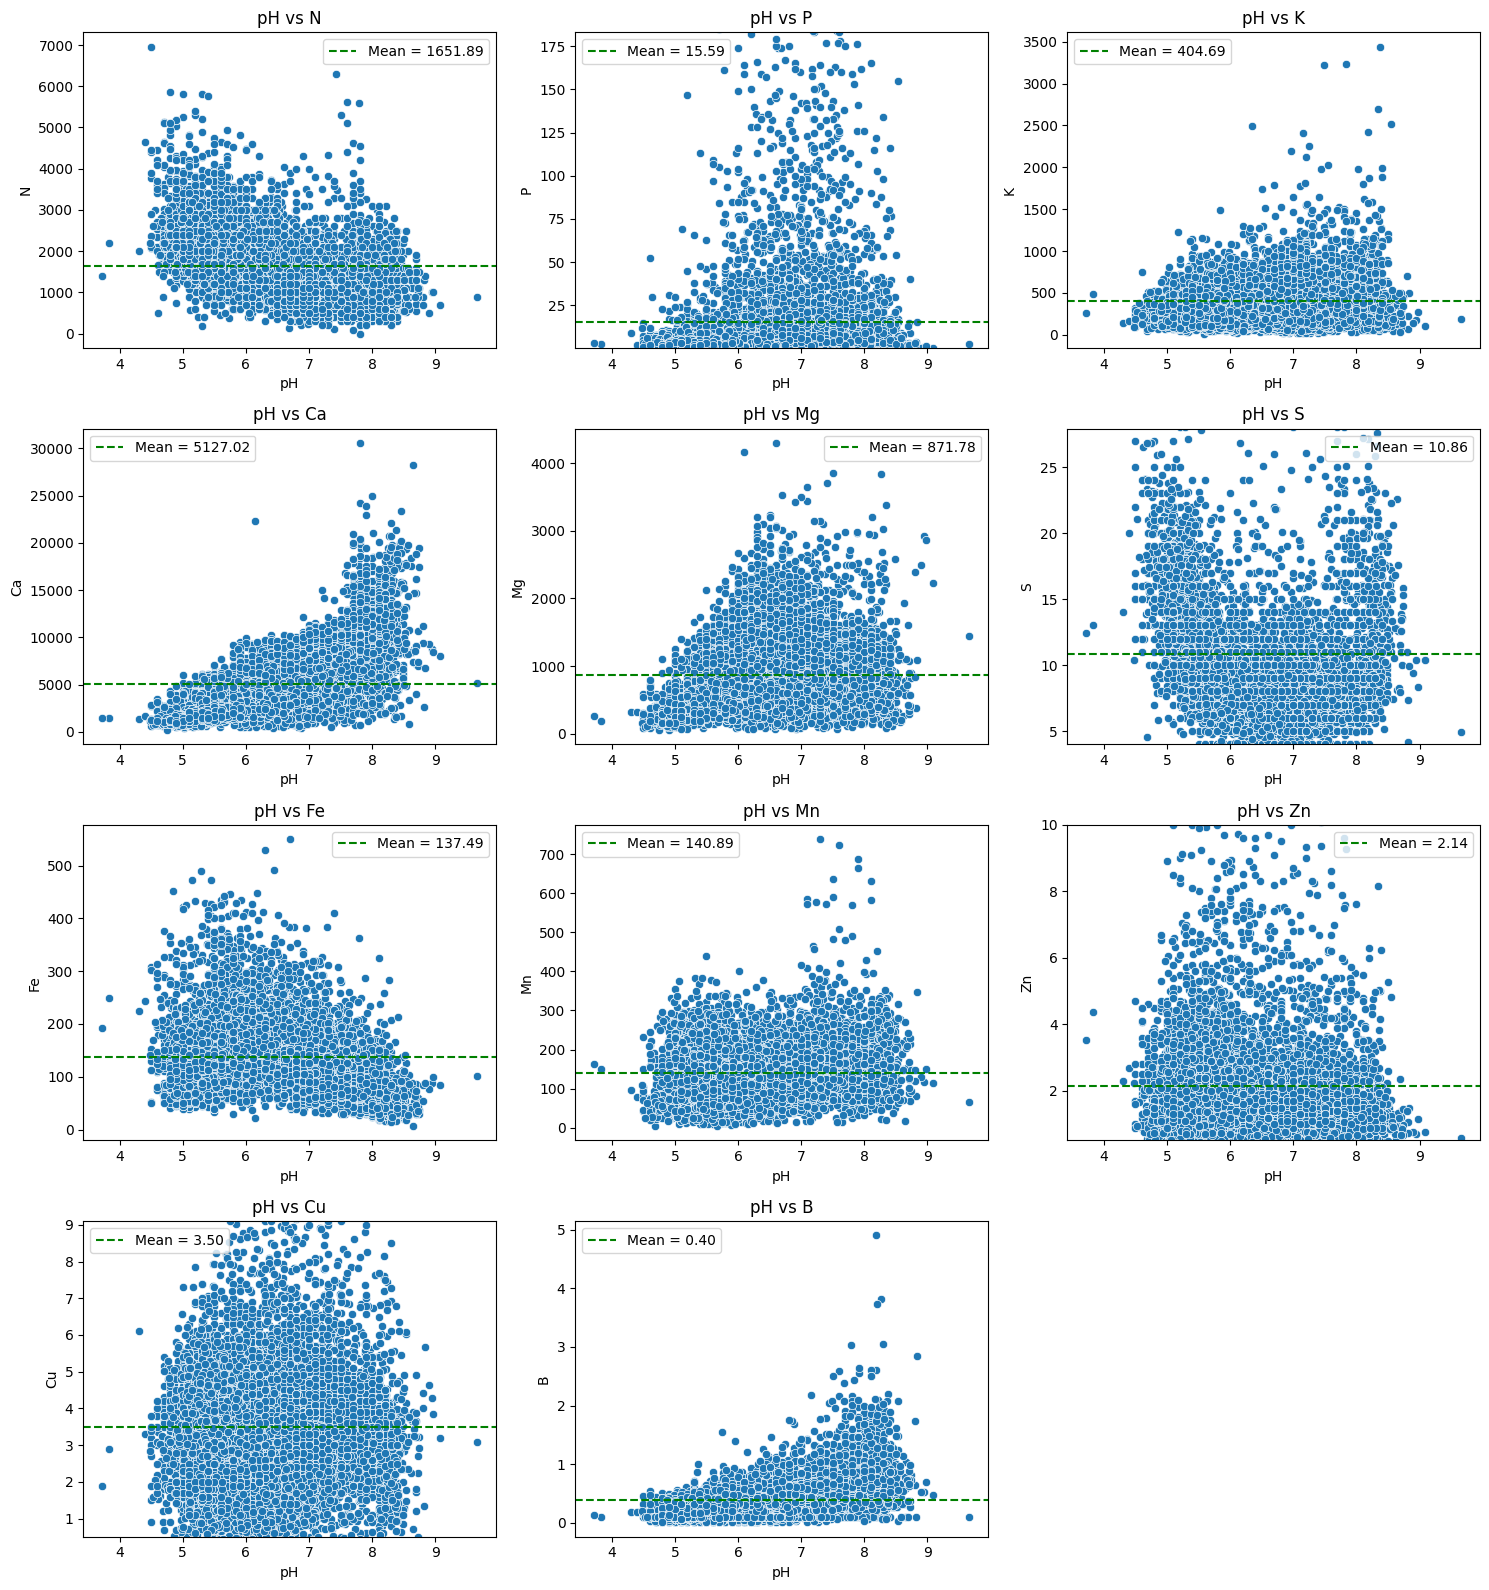

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

feature = 'pH'  # Feature for x-axis
zoom_targets = ['P', 'S', 'Cu', 'Zn']

n = len(target_columns)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, nutrient in enumerate(target_columns):
    plt.subplot(rows, cols, i + 1)
    sns.scatterplot(x=df[feature], y=df[nutrient])
    
    mean_val = df[nutrient].mean()
    plt.axhline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    
    # Zoom y-axis for low variance nutrients
    if nutrient in zoom_targets:
        low, high = df[nutrient].quantile([0.01, 0.99])
        plt.ylim(low, high)
    
    plt.title(f'{feature} vs {nutrient}')
    plt.xlabel(feature)
    plt.ylabel(nutrient)
    plt.legend()

plt.tight_layout()
plt.show()


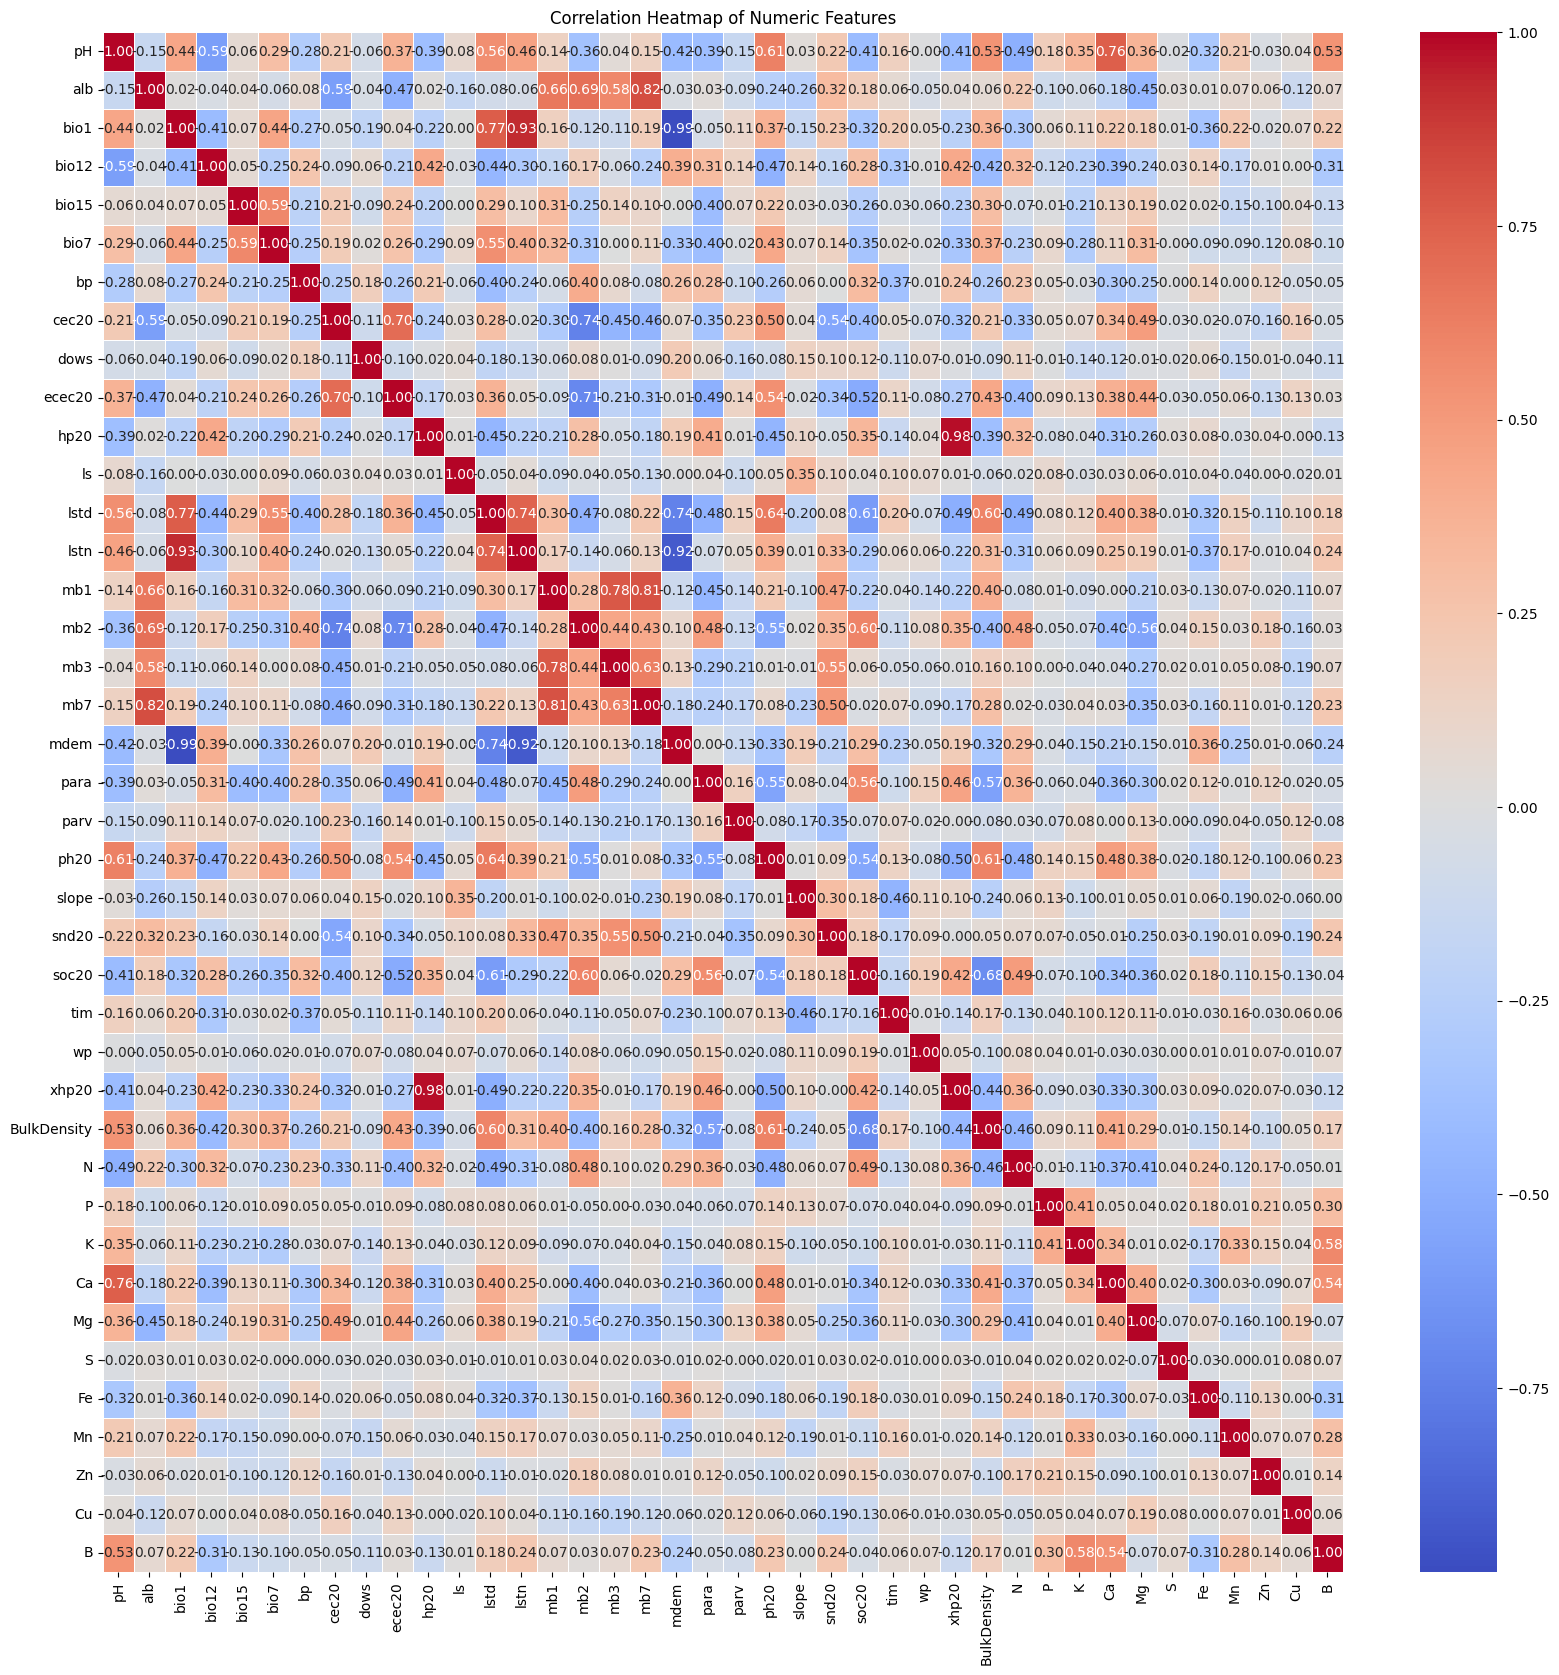

In [96]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
fig_size = (max(12, len(numeric_df.columns) / 2), max(8, len(numeric_df.columns) / 2))
plt.figure(figsize=fig_size)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

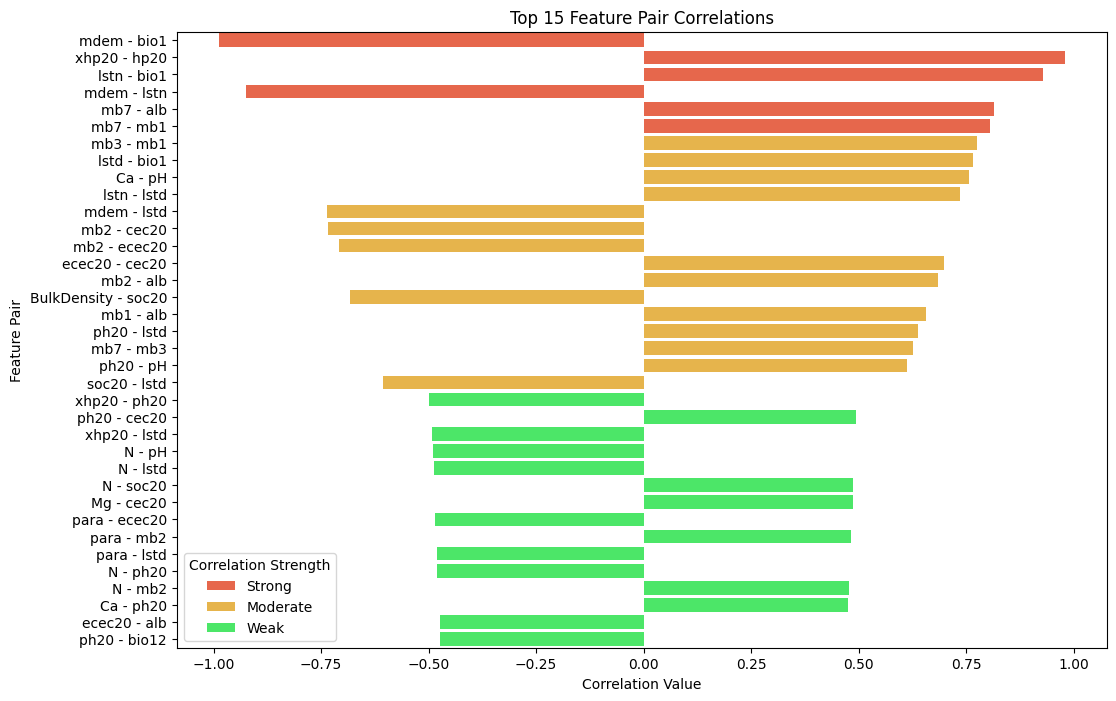

In [97]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if not mask[i, j]: 
            correlations.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))
correlations = sorted(correlations, key=lambda x: abs(x[2]), reverse=True)
strong_threshold = 0.8
moderate_threshold = 0.5
strong_correlations = []
moderate_correlations = []
weak_correlations = []
for feature1, feature2, corr_value in correlations:
    if abs(corr_value) >= strong_threshold:
        strong_correlations.append((feature1, feature2, corr_value))
    elif abs(corr_value) >= moderate_threshold:
        moderate_correlations.append((feature1, feature2, corr_value))
    else:
        weak_correlations.append((feature1, feature2, corr_value))

top_n = 15 
all_correlations = strong_correlations[:top_n] + moderate_correlations[:top_n] + weak_correlations[:top_n]

categories = ['Strong', 'Moderate', 'Weak']
category_labels = ['Strong Correlation (>= 0.8)', 'Moderate Correlation (>= 0.5)', 'Weak Correlation (< 0.5)']
category_colors = ['#FF5733', '#FFBD33', '#33FF57']
feature_pairs = [f'{f1} - {f2}' for f1, f2, _ in all_correlations]
correlation_values = [corr for _, _, corr in all_correlations]
category_indices = ['Strong'] * len(strong_correlations[:top_n]) + ['Moderate'] * len(moderate_correlations[:top_n]) + ['Weak'] * len(weak_correlations[:top_n])
df_corr = pd.DataFrame({
    'Feature Pair': feature_pairs,
    'Correlation Value': correlation_values,
    'Category': category_indices
})

plt.figure(figsize=(12, 8))
sns.barplot(x='Correlation Value', y='Feature Pair', data=df_corr, hue='Category', dodge=False, palette=category_colors)
plt.title(f'Top {top_n} Feature Pair Correlations')
plt.xlabel('Correlation Value')
plt.ylabel('Feature Pair')
plt.legend(title='Correlation Strength')
plt.show()


### Modeling

In [20]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [31]:
X = df.drop(columns=target_columns)
y = df[target_columns]

In [32]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train = X_train.drop(columns=['PID'])
X_val = X_val.drop(columns=['PID'])

In [ ]:
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=150, random_state=42,n_jobs=-1))
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_val)

### Evaluation

In [62]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Compute per-target MSE
mse_per_target = mean_squared_error(y_val, y_pred, multioutput='raw_values')

# Compute per-target R-squared
r2_per_target = r2_score(y_val, y_pred, multioutput='raw_values')


for i, (nutrient, mse, r2) in enumerate(zip(target_columns, mse_per_target, r2_per_target)):
    rmse = np.sqrt(mse)
    print(f"{nutrient}: RMSE = {rmse:.4f}, R² = {r2:.4f}")


N: RMSE = 490.1273, R² = 0.5754
P: RMSE = 43.8039, R² = 0.0275
K: RMSE = 200.3900, R² = 0.4297
Ca: RMSE = 1524.3543, R² = 0.8128
Mg: RMSE = 342.3836, R² = 0.6320
S: RMSE = 16.7708, R² = -0.1277
Fe: RMSE = 43.3229, R² = 0.5661
Mn: RMSE = 54.0586, R² = 0.4113
Zn: RMSE = 1.9886, R² = 0.0776
Cu: RMSE = 5.0299, R² = 0.0471
B: RMSE = 0.2337, R² = 0.5338


In [63]:
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f' RMSE: {rmse:.4f}')

 RMSE: 498.0226


##### There isn't much variation for P, S, Cu and Zn (we can see this with boxplots) that's why models fit them horribly.
##### When R² is negative or very close to 0 we can simply take the mean

### Satelite data

In [2]:
landsat=pd.read_csv(r'LANDSAT8_data_updated.csv')
modis_1 = pd.read_csv(r'MODIS_MOD09GA_data.csv')
modis_2 = pd.read_csv(r'MODIS_MOD11A1_data.csv')
modis_3 = pd.read_csv(r'MODIS_MOD16A2_data.csv')
modis_4 = pd.read_csv(r'MODIS_MOD13Q1_data.csv')
modis_5 = pd.read_csv(r'MODIS_MCD43A4_data.csv')
sentinel_1 = pd.read_csv(r'Sentinel1_data.csv')
sentinel_2 = pd.read_csv(r'Sentinel2_data.csv')

In [9]:
print("MODIS MOD09GA Columns:\n", modis_1.columns, "\n")
print("MODIS MOD11A1 Columns:\n", modis_2.columns, "\n")
print("MODIS MOD16A2 Columns:\n", modis_3.columns, "\n")
print("MODIS MOD13Q1 Columns:\n", modis_4.columns, "\n")
print("MODIS MCD43A4 Columns:\n", modis_5.columns, "\n")
print("Sentinel-1 Columns:\n", sentinel_1.columns, "\n")
print("Sentinel-2 Columns:\n", sentinel_2.columns, "\n")
print("landsat Columns:\n", landsat.columns, "\n")

MODIS MOD09GA Columns:
 Index(['date', 'lat', 'lon', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03',
       'sur_refl_b04', 'sur_refl_b05', 'sur_refl_b06', 'sur_refl_b07', 'PID'],
      dtype='object') 

MODIS MOD11A1 Columns:
 Index(['LST_Day_1km', 'LST_Night_1km', 'date', 'lat', 'lon', 'PID'], dtype='object') 

MODIS MOD16A2 Columns:
 Index(['ET', 'PET', 'date', 'lat', 'lon', 'PID'], dtype='object') 

MODIS MOD13Q1 Columns:
 Index(['EVI', 'NDVI', 'RelativeAzimuth', 'SolarZenith', 'ViewZenith', 'date',
       'lat', 'lon', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03',
       'sur_refl_b07', 'PID'],
      dtype='object') 

MODIS MCD43A4 Columns:
 Index(['Nadir_Reflectance_Band1', 'Nadir_Reflectance_Band2',
       'Nadir_Reflectance_Band3', 'Nadir_Reflectance_Band4', 'date', 'lat',
       'lon', 'PID'],
      dtype='object') 

Sentinel-1 Columns:
 Index(['VH', 'VV', 'date', 'instrumentMode', 'lat', 'lon',
       'orbitProperties_pass', 'relativeOrbitNumber_start', 'PID'],
      dtype=

In [12]:
modis_1['date'] = pd.to_datetime(modis_1['date'])
modis_2['date'] = pd.to_datetime(modis_2['date'])
modis_3['date'] = pd.to_datetime(modis_3['date'])
modis_4['date'] = pd.to_datetime(modis_4['date'])
modis_5['date'] = pd.to_datetime(modis_5['date'])
sentinel_1['date'] = pd.to_datetime(sentinel_1['date'])
sentinel_2['date'] = pd.to_datetime(sentinel_2['date'])
landsat['date'] = pd.to_datetime(landsat['date'])

#### Finding Missing Dates and Missing Values

In [51]:
modis_1['date'] = pd.to_datetime(modis_1['date'])#convert date to date type
unique_dates = pd.Series(modis_1['date'].sort_values().unique())#extract unique dates
diffs = unique_dates.diff().dropna().reset_index(drop=True)
day_diffs = diffs.dt.days
frequency_days = day_diffs.mode()[0]

1
0    1
dtype: int64


In [37]:
satelites = [modis_1, modis_2, modis_3, modis_4, modis_5, sentinel_1, sentinel_2, landsat]
satelite_names = ['modis_1', 'modis_2', 'modis_3', 'modis_4', 'modis_5', 'sentinel_1', 'sentinel_2', 'landsat']

for satelite, satelite_name in zip(satelites, satelite_names):
    satelite['date'] = pd.to_datetime(satelite['date'])#convert date to date type
    unique_dates = pd.Series(satelite['date'].sort_values().unique())#extract unique dates
    diffs = unique_dates.diff().dropna().reset_index(drop=True)#get the difference between dates
    day_diffs = diffs.dt.days#make it numerical
    frequency_days = day_diffs.mode()[0]#get the most frequent diff
    frequency = f"{frequency_days}D"
    first_date = unique_dates.iloc[0]
    last_date = unique_dates.iloc[-1]
    expected_dates = pd.date_range(start=first_date, end=last_date, freq=frequency)
    unique_dates_np = unique_dates.values.astype('datetime64[D]')
    missing_dates = []
    if frequency_days == 1:
        # Exact match, no tolerance needed
        missing_dates = list(set(expected_dates) - set(unique_dates))
    else:
        # ±1 day tolerance for frequencies > 1 day
        for expected_date in expected_dates:
            expected_date_np = np.datetime64(expected_date)
            diff = abs(unique_dates_np - expected_date_np)
            if not (diff <= np.timedelta64(1, 'D')).any():
                missing_dates.append(expected_date)
    
    formatted_dates = [d.strftime("%Y-%m-%d") for d in sorted(missing_dates)]
    
    print(f"{satelite_name}\nEstimated frequency: every {frequency_days} days")
    print(f"Start date: {first_date} \nEnd date : {last_date}")  
    print(f"Missing dates ({len(missing_dates)} out of {len(expected_dates)} expected dates): {formatted_dates}")
    print("—" * 150)


modis_1
Estimated frequency: every 1 days
Start date: 2017-01-01 00:00:00 
End date : 2019-12-30 00:00:00
Missing dates (10 out of 1094 expected dates): ['2017-02-19', '2017-02-20', '2017-02-21', '2017-02-22', '2017-02-23', '2017-02-24', '2017-02-25', '2017-02-26', '2017-02-27', '2018-04-24']
——————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
modis_2
Estimated frequency: every 1 days
Start date: 2017-01-01 00:00:00 
End date : 2019-12-30 00:00:00
Missing dates (46 out of 1094 expected dates): ['2017-02-18', '2017-02-19', '2017-02-20', '2017-02-21', '2017-02-22', '2017-02-23', '2017-02-24', '2017-02-25', '2017-02-26', '2017-02-27', '2017-05-01', '2017-05-05', '2017-06-06', '2017-06-17', '2017-06-23', '2017-07-08', '2017-07-11', '2017-07-27', '2017-07-29', '2017-08-03', '2017-08-06', '2017-08-09', '2017-08-10', '2017-09-26', '2018-04-24', '2018-04-29', '2018-07-21', '2018-08-06', '2018-08-

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
modis_1['date'] = pd.to_datetime(modis_1['date'])
reflectance_cols = [
    'Nadir_Reflectance_Band1', 'Nadir_Reflectance_Band2',
    'Nadir_Reflectance_Band3', 'Nadir_Reflectance_Band4'
]

daily_mean = modis_1.groupby('date')[reflectance_cols].mean().reset_index()

melted = daily_mean.melt(id_vars='date', var_name='Band', value_name='Reflectance')

plt.figure(figsize=(12, 6))
sns.lineplot(data=melted, x='date', y='Reflectance', hue='Band', marker='o')
plt.title('MODIS MCD43A4 - Nadir Reflectance Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Reflectance')
plt.legend(title='Band')
plt.tight_layout()
plt.show()